Лычаный НА N33471

Вариант 2

Задача 1 Nursing Home Data

Импортируем библиотеки.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')

Маунтим Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Открываем датасет из гугл диска

In [3]:
df = pd.read_csv('/content/drive/MyDrive/itmo/3/теория алгоритмов/lab_4/Nursing Home Data/Nursing Home Data_data', sep='\s+')
df.head()

,BED,MCDAYS,TDAYS,PCREV,NSAL,FEXP,RURAL
0,244,128,385,23521,5230,5334,0
1,59,155,203,9160,2459,493,1
2,120,281,392,21900,6304,6115,0
3,120,291,419,22354,6590,6346,0
4,120,238,363,17421,5362,6225,0


In [4]:
with open('/content/drive/MyDrive/itmo/3/теория алгоритмов/lab_4/Nursing Home Data/Nursing Home Data') as file_handler:
  for line in file_handler:
      print(line)

Nursing Home Data




Variable Names: 

BED = 	 number of beds in home 

MCDAYS = annual medical in-patient days (hundreds) 

TDAYS =  annual total patient days (hundreds) 

PCREV =  annual total patient care revenue ($hundreds) 

NSAL =   annual nursing salaries ($hundreds) 

FEXP =   annual facilities expenditures ($hundreds) 

RURAL =  rural (1) and non-rural (0) homes 



Number of cases: 52 



The data were collected by the Department of Social Services of the 

State of New Mexico, and cover 52 of the 60 licensed nursing 

facilities in the state in 1988. The operating statistics are 

number of beds, medical in-patient days, total patient days, total 

patient care revenue, annual nursing salaries, and annual facilities 

expenditures for rural and non-rural nursing homes. 



These data are part of the data analyzed in 

Howard L. Smith, Niell F. Piland, and Nancy Fisher, 

"A Comparison of Financial Performance, Organizational 

Characteristics, and Management Strategy Among 

Размаунтим Google Drive

In [5]:
drive.flush_and_unmount()

In [6]:
df.groupby('RURAL').count()

,BED,MCDAYS,TDAYS,PCREV,NSAL,FEXP
RURAL,,,,,,
0,18,18,18,18,18,18
1,34,34,34,34,34,34


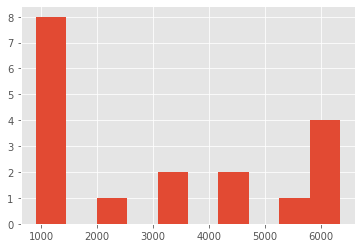

In [7]:
df[df['RURAL']==0]['FEXP'].hist()

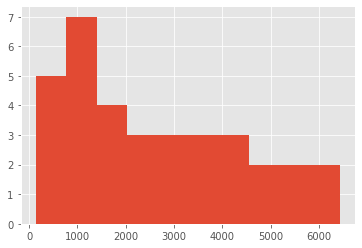

In [8]:
df[df['RURAL']==1]['FEXP'].hist()

Количество загородных: 34
Количество городских: 18

У нас 52 наблюдения, поэтому нельзя однозначно сказать, какой из критериев для определения нормальности распределения использовать. 
Оба этих критерия проверяют гипотезу о нормальности распределения данных:

In [9]:
sc.stats.kstest(df[df['RURAL']==1]['FEXP'].values, 'norm')

KstestResult(statistic=1.0, pvalue=0.0)

In [10]:
sc.stats.kstest(df[df['RURAL']==0]['FEXP'].values, 'norm')

KstestResult(statistic=1.0, pvalue=0.0)

pvalue = 0 < 0.05  ==> гипотеза нормального распределения отвергается
И так, распределение расходы для обеих подгрупп  не является нормальным. 
Однако, возможно, что распределение несущественно отличается от нормального

/usr/local/lib/python3.6/dist-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


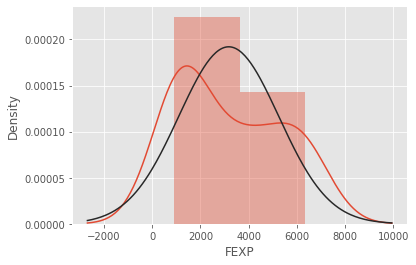

In [11]:
sns.distplot(df[df['RURAL']==0]['FEXP'] , fit=sc.stats.norm)

/usr/local/lib/python3.6/dist-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


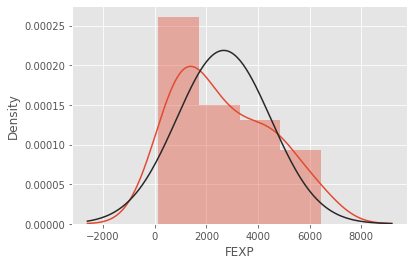

In [12]:
sns.distplot(df[df['RURAL']==1]['FEXP'] , fit=sc.stats.norm)

Итак, распределение расходов для обеих подгрупп даже является  отличным от нормального. 
Следовательно, для сравнения расходов больниц мы не можем пользоваться сравнением средних этих двух совокупностей.

Проверка равенства медиан
Для проверки гипотезы о равенстве медиан используем критерий Манна-Уитни для независимых выборок. Он проверяет следующую гипотезу:

Н: медианы равны
К: медианы не равны

Для вычисления Критерия Манна-Уитни используем точный способ вычисления р-значений (опция Exact). Получаем следующие результаты:

In [13]:
sc.stats.mannwhitneyu(df[df['RURAL']==1]['FEXP'].values, df[df['RURAL']==0]['FEXP'].values)

MannwhitneyuResult(statistic=273.0, pvalue=0.26594759448891914)

pvalue > 0.05 ==> гипотеза о равенстве медиан не отвергнута.
Интерпретируем результат: расходы за городом и расходы можно считать примерно равным. 


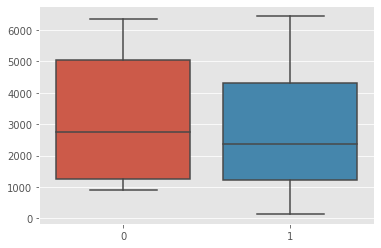

In [14]:
ax = sns.boxplot(x=df['RURAL'].values, y=df['FEXP'].values )
plt.show()

Задача 2 Unions and State Labor Law

In [15]:
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
df = pd.read_csv('/content/drive/MyDrive/itmo/3/теория алгоритмов/lab_4/Unions and State Labor Law/Unions and State Labor Law_data', sep='\s+')
df.head()

,STATE,DENS,COMP,RTW,PVT
0,NY,56.9,1,0,31.2
1,MI,49.6,1,0,30.2
2,WA,32.4,1,0,33.1
3,HI,54.6,1,0,24.7
4,AK,30.7,1,0,30.1


In [17]:
with open('/content/drive/MyDrive/itmo/3/теория алгоритмов/lab_4/Unions and State Labor Law/Unions and State Labor Law') as file_handler:
  for line in file_handler:
      print(line)

Unions and State Labor Law




Variable Names: 

DENS: 	Percent of public sector employees in unions, 1982 

COMP: 	State bargaining laws cover public employees (1) or not (0) 

RTW: 	State right-to-work law (1) or not (0) 

PVT: 	Percent of private sector employees in unions, 1982 



Number of cases: 50 





Meltz analyzed factors associated with differences in the percent  of public

sector employees belonging to unions by states in the United States and

by provinces in Canada. While he did not run formal regression analyses, 

he finds the major source of difference in public union density to be the 

differences in percent of private sector employees in unions.



The dummy variables for presence of state bargaining laws covering public

employees and presence of state right to work laws in the datafile provide

an opportunity to examine a two-predictor regression involving dummy 

variables. In this case there is interaction between the two dummy 

variables and this calls for 

In [18]:
drive.flush_and_unmount()

In [19]:
df.groupby('RTW').count()

,STATE,DENS,COMP,PVT
RTW,,,,
0,30,30,30,30
1,20,20,20,20


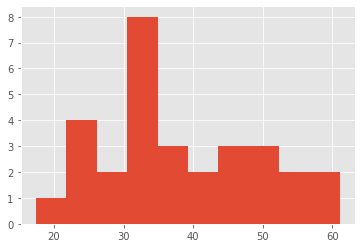

In [20]:
df[df['RTW']==0]['DENS'].hist()


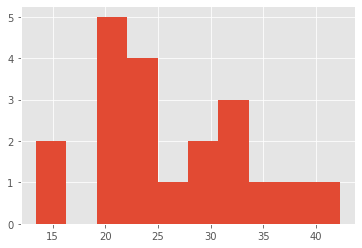

In [21]:
df[df['RTW']==1]['DENS'].hist()


Закон принят: 20
Закон не принят: 30

У нас 52 наблюдения, поэтому нельзя однозначно сказать, какой из критериев для определения нормальности распределения использовать. Оба этих критерия проверяют гипотезу о нормальности распределения данных:

In [22]:
sc.stats.kstest(df[df['RTW']==1]['DENS'].values, 'norm')

KstestResult(statistic=1.0, pvalue=0.0)

In [23]:
sc.stats.kstest(df[df['RTW']==0]['DENS'].values, 'norm')

KstestResult(statistic=1.0, pvalue=0.0)

pvalue = 0 < 0.05 ==> гипотеза нормального распределения отвергается И так, распределение расходы для обеих подгрупп не является нормальным. Однако, возможно, что распределение несущественно отличается от нормального

/usr/local/lib/python3.6/dist-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


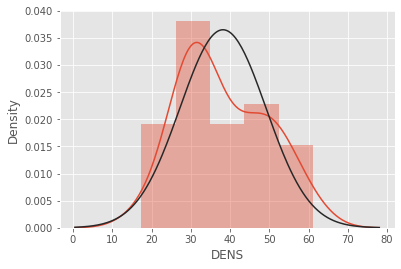

In [24]:
sns.distplot(df[df['RTW']==0]['DENS'] , fit=sc.stats.norm)

/usr/local/lib/python3.6/dist-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


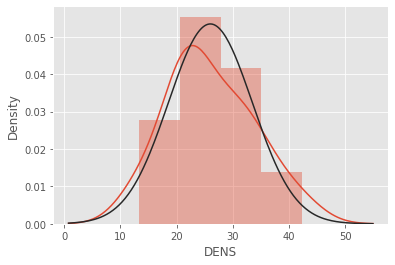

In [28]:
sns.distplot(df[df['RTW']==1]['DENS'] , fit=sc.stats.norm)

Итак, распределение расходов для обеих подгрупп даже является отличным от нормального. Следовательно, для сравнения расходов больниц мы не можем пользоваться сравнением средних этих двух совокупностей.

Проверка равенства медиан Для проверки гипотезы о равенстве медиан используем критерий Манна-Уитни для независимых выборок. Он проверяет следующую гипотезу:

Н: медианы равны К: медианы не равны

Для вычисления Критерия Манна-Уитни используем точный способ вычисления р-значений (опция Exact). Получаем следующие результаты:

In [26]:
sc.stats.mannwhitneyu(df[df['RTW']==1]['DENS'].values, df[df['RTW']==0]['DENS'].values)

MannwhitneyuResult(statistic=112.5, pvalue=0.00010624487970362637)

p-value < 0.05 ==> гипотеза о равенстве медиан  отвергнута.
Интерпретируем результат: принят и не принят в этих штатах соответствующий закон не можно считать примерно равным. 

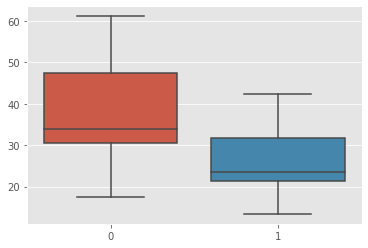

In [27]:
ax = sns.boxplot(x=df['RTW'].values, y=df['DENS'].values )
plt.show()